Fetching career advanced stats for: James Harden
Attempting to navigate to URL: https://www.basketball-reference.com/players/h/hardeja01.html
Page loaded and advanced stats table (ID='advanced') found.
Browser closed.

--- Raw Data Scraped ---
    Season Team  BPM
0  2009-10  OKC  0.5
1  2010-11  OKC  1.9
2  2011-12  OKC  4.3
3  2012-13  HOU  5.6
4  2013-14  HOU  5.6

--- Cleaned Data for Plotting ---
Successfully cleaned and processed 16 unique seasons of BPM data for James Harden.
     Season   BPM
0   2009-10   0.5
1   2010-11   1.9
2   2011-12   4.3
3   2012-13   5.6
4   2013-14   5.6
5   2014-15   8.8
6   2015-16   6.6
7   2016-17   8.7
8   2017-18   9.9
9   2018-19  11.0
10  2019-20   9.6
11  2020-21   7.7
12  2021-22   3.8
13  2022-23   5.4
14  2023-24   4.1
15  2024-25   4.3


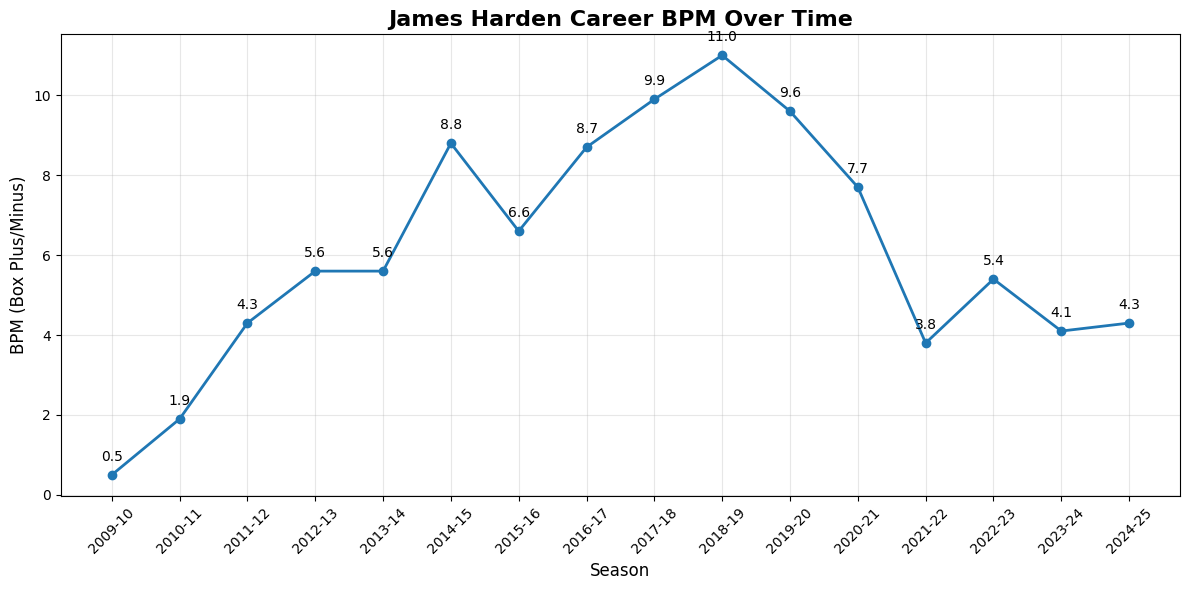

In [32]:
import pandas as pd
from bs4 import BeautifulSoup
import io # Import the 'io' module to handle the FutureWarning


import pandas as pd
from bs4 import BeautifulSoup

# Import the necessary components from Selenium
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service as ChromeService
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import unidecode

def get_player_data_with_selenium(player_name):
    """
    Fetches the player's advanced stats table using Selenium.
    This version looks for the table directly, not in a comment.
    """
    driver = None
    try:
        # --- Construct the URL ---
        normalized_name = unidecode.unidecode(player_name).lower()
        parts = normalized_name.split()
        first_name = parts[0]
        last_name = parts[-1]
        last_name_five = last_name[:5]
        first_name_two = first_name[:2]
        last_name_initial = last_name[0]
        player_code = f"{last_name_five}{first_name_two}01"
        url = f"https://www.basketball-reference.com/players/{last_name_initial}/{player_code}.html"
        print(f"Attempting to navigate to URL: {url}")

        # --- Set up and launch the Chrome browser ---
        service = ChromeService(ChromeDriverManager().install())
        driver = webdriver.Chrome(service=service)
        driver.get(url)

        # --- Wait for the table to be loaded ---
        WebDriverWait(driver, 30).until(
            EC.presence_of_element_located((By.ID, "advanced"))
        )
        print("Page loaded and advanced stats table (ID='advanced') found.")

        # --- Find the table directly ---
        soup = BeautifulSoup(driver.page_source, 'html.parser')
        stats_table = soup.find('table', id='advanced')

        if stats_table:
            # Use io.StringIO to address the FutureWarning
            df = pd.read_html(io.StringIO(str(stats_table)))[0]
            # Clean up repeating header rows that might exist
            df = df[df['Season'] != 'Season'].reset_index(drop=True)
            return df
        else:
            print("Could not parse the advanced stats table directly.")
            return None

    except Exception as e:
        print(f"An error occurred during the Selenium process: {e}")
        return None
    finally:
        if driver:
            driver.quit()
            print("Browser closed.")


# --- Main script execution ---
player_name = "James Harden"
print(f"Fetching career advanced stats for: {player_name}")
harden_stats_raw = get_player_data_with_selenium(player_name)

if harden_stats_raw is not None and not harden_stats_raw.empty:
    print("\n--- Raw Data Scraped ---")
    print(harden_stats_raw[['Season', 'Team', 'BPM']].head()) # Show a snippet of raw data

    # --- NEW: Advanced Data Cleaning Logic ---
    
    # 1. Convert BPM to numeric, coercing errors to NaN (Not a Number)
    harden_stats_raw['BPM'] = pd.to_numeric(harden_stats_raw['BPM'], errors='coerce')
    # Drop rows where BPM is NaN (these are often header/invalid rows)
    cleaned_stats = harden_stats_raw.dropna(subset=['BPM'])

    # 2. Handle mid-season trades: For seasons that appear more than once,
    #    we only want the 'TOT' (Total) row.
    #    We can do this by dropping duplicates on 'Season', keeping the last entry,
    #    as 'TOT' rows always appear last for a given year.
    cleaned_stats = cleaned_stats.drop_duplicates(subset='Season', keep='last')

    # 3. Filter to keep only valid season rows using a regular expression.
    #    A valid season looks like "2009-10". This removes "16 Yrs", "OKC (3 Yrs)", etc.
    season_pattern = r'^\d{4}-\d{2}$'
    cleaned_stats = cleaned_stats[cleaned_stats['Season'].str.match(season_pattern)]
    
    # 4. Finalize the DataFrame for plotting
    harden_bpm_final = cleaned_stats[['Season', 'BPM']].copy().reset_index(drop=True)

    print(f"\n--- Cleaned Data for Plotting ---")
    print(f"Successfully cleaned and processed {len(harden_bpm_final)} unique seasons of BPM data for James Harden.")
    print(harden_bpm_final)
    
    # --- Create time graph (your existing code is fine) ---
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(12, 6))
    plt.plot(harden_bpm_final['Season'], harden_bpm_final['BPM'], marker='o', linewidth=2, markersize=6)
    plt.title('James Harden Career BPM Over Time', fontsize=16, fontweight='bold')
    plt.xlabel('Season', fontsize=12)
    plt.ylabel('BPM (Box Plus/Minus)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    for i, row in harden_bpm_final.iterrows():
        plt.annotate(f'{row["BPM"]:.1f}', 
                    (row['Season'], row['BPM']), 
                    textcoords="offset points", 
                    xytext=(0,10), 
                    ha='center')
    
    plt.show()

else:
    print(f"Could not retrieve advanced stats for {player_name}.")